# Wine Quality Prediction Using Machine Learning

## Task 2 — Wine Quality Prediction

### Objective

Predict wine-quality categories from physicochemical characteristics — measurable chemical properties like
acidity, sugar, and alcohol content — and compare three classification algorithms: **Random Forest**,
**Stochastic Gradient Descent (SGD) Classifier**, and **Support Vector Classifier (SVC)**.

### Why wine-quality prediction is useful

Wine quality is normally assessed by human tasters, which is slow, subjective, and expensive to scale. A
model that links measurable chemical properties to quality ratings could support (not replace) that process
in several realistic ways:

- **Quality-control support** — flagging batches whose chemistry deviates from what typically scores well,
  before they reach a human taster
- **Production analysis** — helping producers understand which chemical properties tend to accompany
  higher-rated wines
- **Screening for further human evaluation** — prioritising which samples get closer expert attention
- **Decision support for producers** — informing production adjustments (e.g. acidity, sulphate levels)

This notebook does **not** claim the resulting model can replace professional wine tasting — the results in
Steps 20–21 will show exactly how strong (and how limited) this kind of model actually is, and the
conclusion is scoped to what the evidence supports.

### Dataset

The **Wine Quality dataset** (Cortez et al., 2009), UCI Machine Learning Repository. There are separate
red-wine and white-wine versions of this dataset — **this notebook uses the red-wine dataset**
(`winequality.csv`, confirmed against its actual column names and row count in Step 3).


## Step 2 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## Step 3 — Load the Dataset

In [2]:
df = pd.read_csv("data/winequality.csv")

print("Shape:", df.shape)
df.head()

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [4]:
df.shape

(1599, 12)

In [5]:
df.columns.tolist()

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


**What the dataset contains:**

- **Rows:** 1,599 red wine samples
- **Columns:** 12 — 11 physicochemical measurement features plus the `quality` target
- **Feature columns (all numeric, float64):** `fixed acidity`, `volatile acidity`, `citric acid`,
  `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates`,
  `alcohol`
- **Target column:** `quality` — an integer score assigned by wine tasters (confirmed range examined in
  Step 5)
- **Data types:** every feature is a continuous numeric measurement (`float64`); `quality` is an integer
  (`int64`). There are no categorical columns to encode, and no separate identifier column.


## Step 4 — Data Quality Check

In [8]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

**No missing values found** in any of the 12 columns — stated explicitly per the project rules.

In [9]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)
print("As a percentage of the dataset:", round(duplicate_count / len(df) * 100, 2), "%")

Duplicate rows: 240
As a percentage of the dataset: 15.01 %


In [10]:
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(6)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
142,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.9916,3.68,0.79,14.0,6
144,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.9916,3.68,0.79,14.0,6
131,5.6,0.50,0.09,2.3,0.049,17.0,99.0,0.9937,3.63,0.63,13.0,5
132,5.6,0.50,0.09,2.3,0.049,17.0,99.0,0.9937,3.63,0.63,13.0,5
1488,5.6,0.54,0.04,1.7,0.049,5.0,13.0,0.9942,3.72,0.58,11.4,5
1491,5.6,0.54,0.04,1.7,0.049,5.0,13.0,0.9942,3.72,0.58,11.4,5


**240 duplicate rows were found — about 15% of the dataset.** This needs to be treated carefully rather
than dismissed automatically:

1. **Why this matters:** each row here is a full 12-value physicochemical fingerprint (11 continuous
   measurements plus quality). The chance of two genuinely different wine samples coincidentally matching on
   every single measurement, several of them to two or three decimal places, is extremely small. Duplicate
   rows this specific are far more likely to be the same sample recorded more than once than two distinct
   wines that happen to share identical chemistry — this is a known, previously documented characteristic of
   this particular UCI dataset.
2. **Why it's a problem if left in:** repeated rows let the same underlying sample influence the model (and
   the train/test split) more than once, inflating its effective weight and risking the same physical sample
   appearing in both the training and test sets — a subtle form of data leakage that would make test
   performance look better than the model's true generalisation ability.
3. **Chosen treatment:** duplicate rows are removed, keeping the first occurrence of each.
4. **Rows affected:** printed below, exactly as found — not estimated.


In [11]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df)

print("Rows before removing duplicates:", rows_before)
print("Duplicate rows removed         :", rows_before - rows_after)
print("Rows remaining                 :", rows_after)

Rows before removing duplicates: 1599
Duplicate rows removed         : 240
Rows remaining                 : 1359


In [12]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

### Checking for invalid or suspicious chemical values

Rather than assuming the data is clean, the actual minimum and maximum of every feature are checked against
what is physically plausible for wine chemistry (e.g. no negative concentrations, no pH outside a realistic
range for wine).

In [13]:
df.describe().loc[["min", "max"]]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
min,4.6,0.12,0.0,0.9,0.012,1.0,6.0,0.99007,2.74,0.33,8.4,3.0
max,15.9,1.58,1.0,15.5,0.611,72.0,289.0,1.00369,4.01,2.00,14.9,8.0


**Finding:** every feature's minimum is a small positive number (nothing negative, nothing at exactly
zero for measurements that couldn't realistically be zero, such as density or pH) and every maximum falls
within a plausible range for wine chemistry (e.g. `pH` between about 2.7 and 4.0, `alcohol` between about
8.4% and 14.9%). No impossible or clearly corrupted values were found, so **no rows are removed or altered
for invalid values** — only the genuine duplicates identified above were removed.

## Step 5 — Target Variable Analysis

In [14]:
df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

In [15]:
(df["quality"].value_counts(normalize=True).sort_index() * 100).round(2)

quality
3     0.74
4     3.90
5    42.46
6    39.37
7    12.29
8     1.25
Name: proportion, dtype: float64

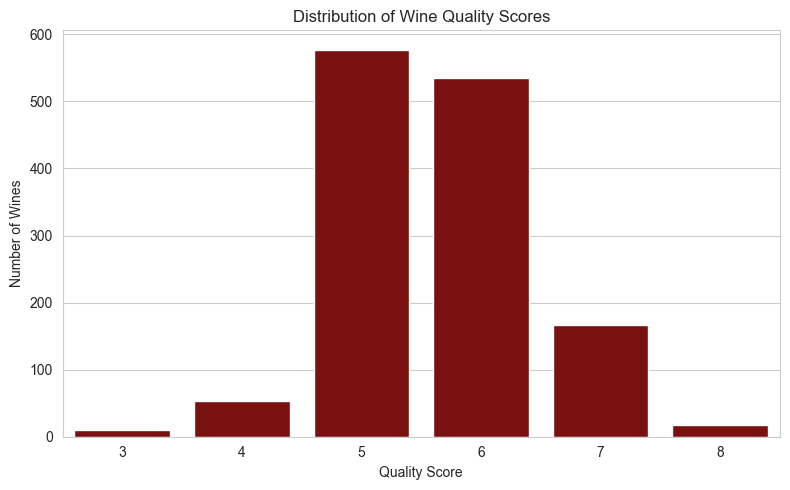

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="quality", color="#8B0000")
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.tight_layout()
plt.show()

**Observations (after removing duplicates):**

- The **most common score is 5** (577 wines, ~42%), closely followed by **6** (535 wines, ~39%) — together
  these two scores make up over 80% of the dataset.
- The **least common scores are 3** (only 10 wines) **and 8** (only 17 wines) — together barely 2% of the
  data.
- Scores **4** (53 wines) and **7** (167 wines) sit in between.
- The target is **not balanced**. Quality scores cluster heavily around the middle (5 and 6), with very few
  examples at either extreme (3 or 8). This is examined formally in Step 6.


## Step 6 — Discuss Class Imbalance

**What class imbalance means:** when one or more classes in a classification target have far fewer examples
than others, so the model sees a lopsided sample of what each class "looks like" during training.

**How it can affect classification here, based on the actual distribution above:**

- With only **10** examples of quality 3 and **17** of quality 8 in the whole 1,359-row dataset, an 80/20
  split would leave roughly 2 and 3 examples of those scores in the test set respectively — far too few to
  draw any reliable conclusion about how well a model predicts those specific scores.
- A model can achieve a deceptively high **overall accuracy** simply by predicting the majority scores (5
  and 6) most of the time, while never correctly identifying a quality-3 or quality-8 wine at all — this is
  exactly the scenario the project's evaluation approach (Steps 17–18: precision/recall/F1 alongside
  accuracy, both weighted and macro averages) is designed to catch, rather than reporting accuracy alone.
- Given how few examples exist for scores 3, 4, and 8, treating each of the six original scores as its own
  class would make several of them essentially untrainable and unevaluable with this dataset size. This
  directly motivates the target-grouping decision made in Step 9.

**Severity, based on the actual counts:** this is a **severe** imbalance — the two smallest classes (3 and 8)
combined make up under 2% of the dataset, and the two largest (5 and 6) make up over 80%. This is not treated
as a minor consideration; it actively shapes the modelling decisions in the rest of this notebook.


## Step 7 — Exploratory Data Analysis

Distributions of all 11 physicochemical features, to look for skew, unusual concentrations of values, and
potential outliers.

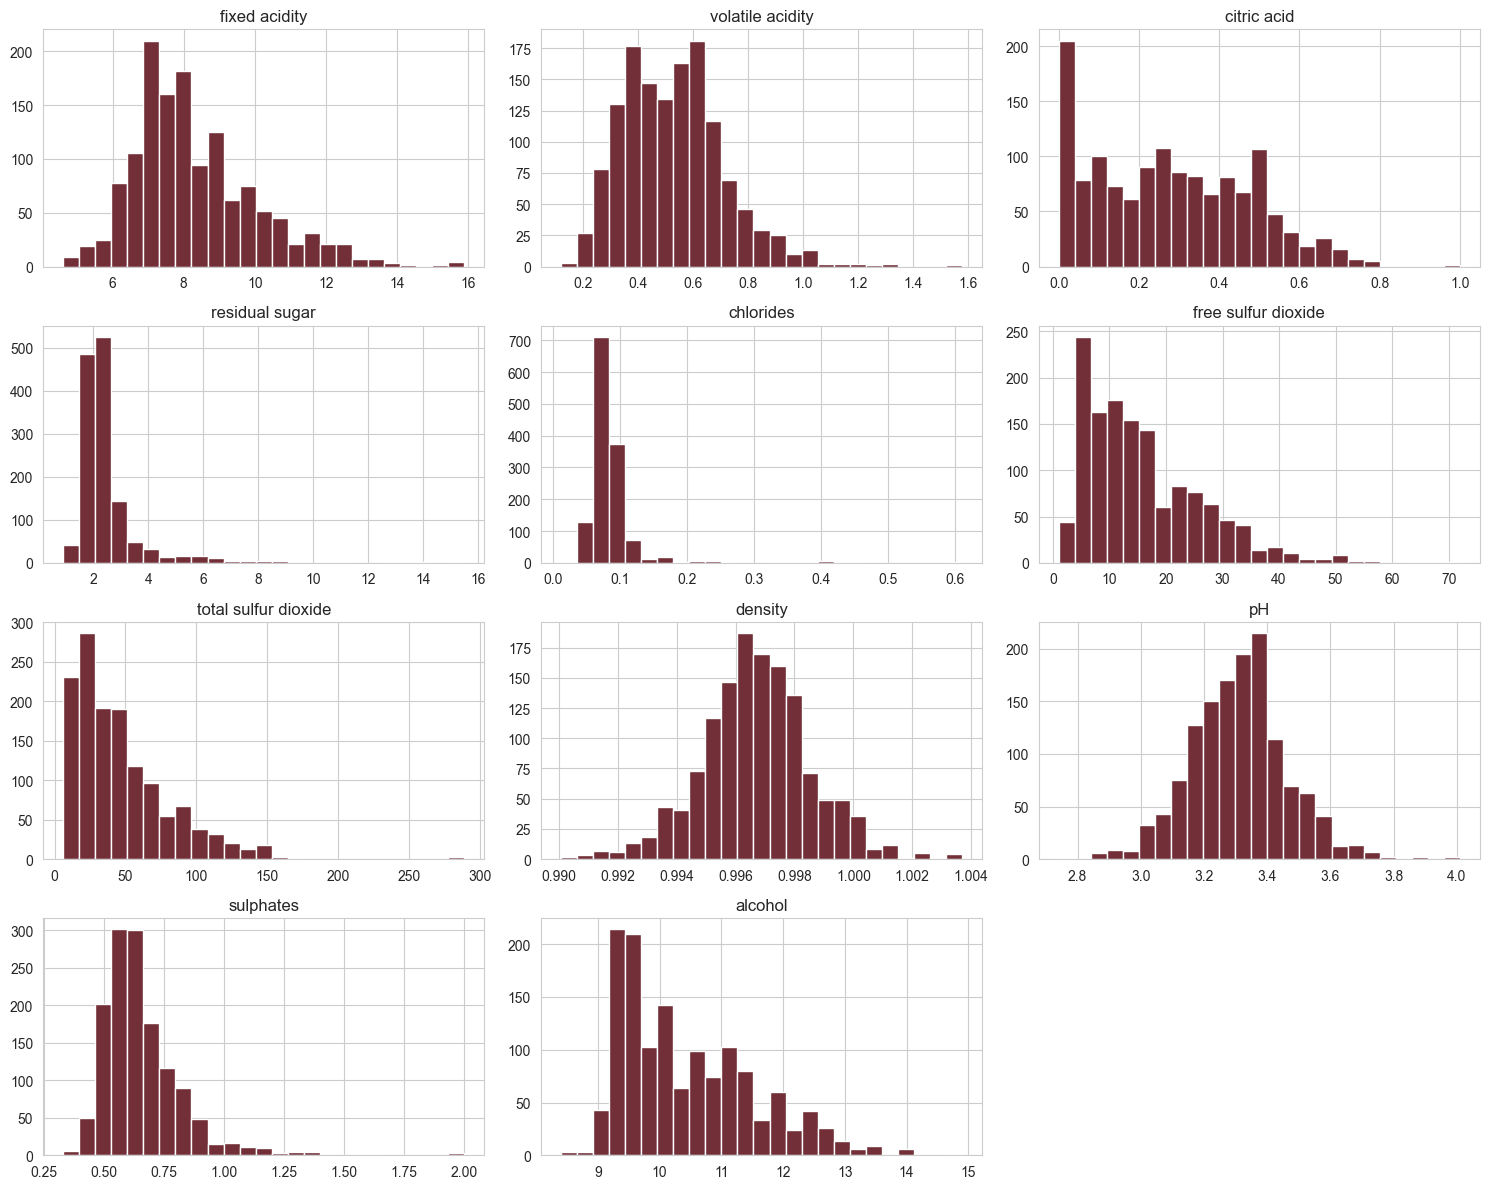

In [17]:
df.drop(columns=["quality"]).hist(figsize=(15, 12), bins=25, color="#722F37", edgecolor="white")
plt.tight_layout()
plt.show()

In [18]:
df.drop(columns=["quality"]).skew().sort_values(ascending=False)

chlorides               5.502487
residual sugar          4.548153
sulphates               2.406505
total sulfur dioxide    1.540368
free sulfur dioxide     1.226579
fixed acidity           0.941041
alcohol                 0.859841
volatile acidity        0.729279
citric acid             0.312726
pH                      0.232032
density                 0.044778
dtype: float64

**Observations:**

- Several features are **strongly right-skewed** — `chlorides`, `residual sugar`, and `sulphates` in
  particular have long tails toward high values, with most wines clustered at the low end and a smaller
  number of wines with noticeably higher concentrations. `total sulfur dioxide` and `free sulfur dioxide`
  show the same pattern.
- `fixed acidity`, `volatile acidity`, and `citric acid` are moderately right-skewed.
- `density` and `pH` are the most symmetric, closest-to-normal-looking distributions of the group — sensible,
  since both properties are constrained by the chemistry and physics of wine to a fairly narrow band.
- The right-skewed features above are the ones most likely to contain the potential outliers a boxplot or IQR
  check would flag (visible as the long right tails in the histograms). These are **not** removed here: the
  project's Step 4 process (identify → explain → decide → apply → document) only applies to genuinely invalid
  values, and a wine with an unusually high but chemically plausible sulphate or sugar reading is a legitimate
  observation, not a data-entry error, unless shown otherwise.
- These are observations about the shape of the data only — **no claims are made here about which of these
  features causes higher or lower quality**; that requires the correlation analysis (Step 8) and later the
  model's feature importance (Step 19), and even those show association, not causation.


## Step 8 — Correlation Heatmap

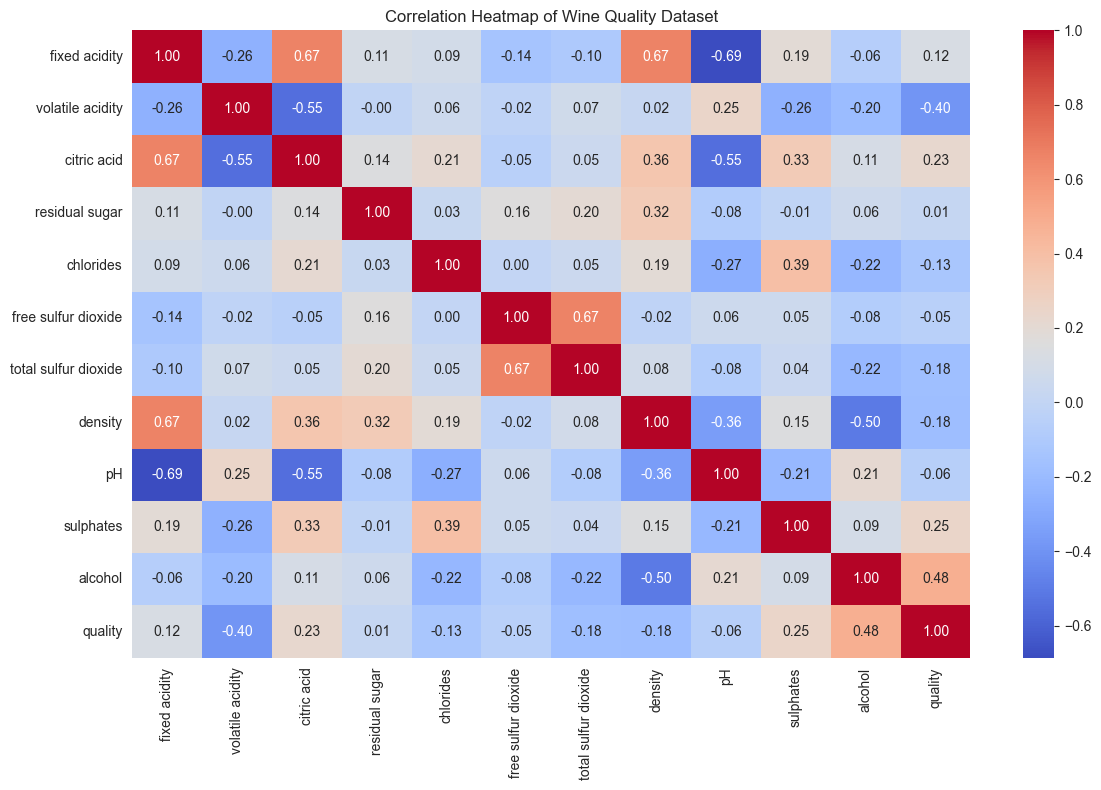

In [19]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation Heatmap of Wine Quality Dataset")
plt.tight_layout()
plt.show()

In [20]:
correlation_matrix["quality"].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64

**Relationship between chemical features and `quality`:**

- **Strongest positive correlation:** `alcohol` (≈ 0.48) — noticeably ahead of every other feature.
  `sulphates` (≈ 0.25) and `citric acid` (≈ 0.23) are next, both positive but much weaker.
- **Strongest negative correlation:** `volatile acidity` (≈ −0.40) — wines with more volatile acidity (which
  contributes a vinegar-like taste at high levels) tend to score lower. `density` (≈ −0.18) and
  `total sulfur dioxide` (≈ −0.18) are weaker negative correlates.
- **Weakest relationships with quality:** `residual sugar` (≈ 0.01), `free sulfur dioxide` (≈ −0.05), and
  `pH` (≈ −0.06) — all close to zero, suggesting little direct linear relationship with the quality score on
  their own.

**Highly correlated predictor pairs** (worth noting for interpretation, since correlated predictors can make
individual coefficients/importances harder to interpret in isolation): `fixed acidity` and `pH` (≈ 0.69,
negative direction — makes chemical sense, since pH is a direct measure of acidity), `fixed acidity` and
`density` (≈ 0.67), `fixed acidity` and `citric acid` (≈ 0.67), and `free sulfur dioxide` with
`total sulfur dioxide` (≈ 0.67, expected since free SO₂ is a component of total SO₂).

**Important:** these are correlations — associations found in this specific dataset — not evidence that any
of these chemical properties *causes* wine quality to rise or fall. A confounding factor (e.g. grape variety
or winemaking technique, neither of which is recorded here) could influence both a chemical measurement and
the taster's quality score independently.

## Step 9 — Feature Engineering / Target Grouping

**Revisiting the original quality distribution (Steps 5–6):** six raw scores (3–8), two of which (3 and 8)
have fewer than 20 examples each in the full 1,359-row dataset, and over 80% of the data concentrated in just
two adjacent scores (5 and 6).

**Decision: group the quality scores into three broader classes** — `Low`, `Medium`, `High` — rather than
keeping all six original scores or collapsing to a binary split. Reasoning:

- **Keeping all six raw scores** would leave several classes with far too few training/test examples to
  learn or evaluate reliably (Step 6) — an 80/20 split would leave only 2–3 test examples for scores 3 and 8.
- **A binary split** (e.g. "Good" vs. "Not Good") would discard the meaningful middle ground in the data —
  the vast majority of wines score 5 or 6, and collapsing that large "typical" group in with either extreme
  would blur a real and useful distinction between merely typical and genuinely above-average wine.
- **Three classes strikes a balance**: it keeps a meaningful middle category (matching where most of the
  actual data sits) while still giving every group enough examples to train and evaluate on, and it maps
  onto an intuitive, defensible real-world framing (below-average / typical / above-average).

**Boundaries chosen**, based on where the actual score distribution naturally clusters (Step 5):

```text
Low     : quality <= 4   (scores 3–4 — below-average wines)
Medium  : quality in {5, 6}  (scores 5–6 — the two dominant, "typical" scores)
High    : quality >= 7   (scores 7–8 — above-average wines)
```

These boundaries were **not** chosen by trial-and-error to maximise model accuracy — they follow directly
from the natural break in the histogram (Step 5) between the sparse tails (3, 4, and 7, 8) and the dense
middle (5, 6), and are a commonly used grouping for this exact dataset in the wine-quality literature.

In [21]:
def group_quality(score):
    if score <= 4:
        return "Low"
    elif score <= 6:
        return "Medium"
    else:
        return "High"

df["quality_group"] = df["quality"].apply(group_quality)

df["quality_group"].value_counts()

quality_group
Medium    1112
High       184
Low         63
Name: count, dtype: int64

In [22]:
(df["quality_group"].value_counts(normalize=True) * 100).round(2)

quality_group
Medium    81.82
High      13.54
Low        4.64
Name: proportion, dtype: float64

C:\Users\user\AppData\Local\Temp\ipykernel_11420\161272063.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="quality_group", order=order_groups, palette=["#B0413E", "#D4A017", "#4C7A3D"])


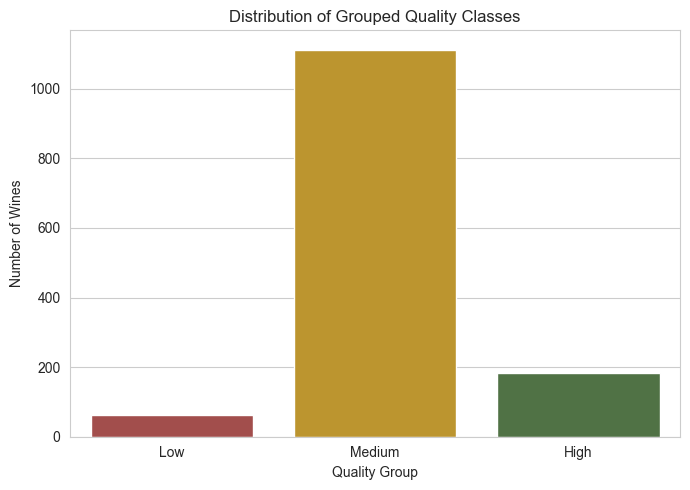

In [23]:
plt.figure(figsize=(7, 5))
order_groups = ["Low", "Medium", "High"]
sns.countplot(data=df, x="quality_group", order=order_groups, palette=["#B0413E", "#D4A017", "#4C7A3D"])
plt.title("Distribution of Grouped Quality Classes")
plt.xlabel("Quality Group")
plt.ylabel("Number of Wines")
plt.tight_layout()
plt.show()

**Resulting distribution:** `Medium` 1,112 wines (~81.8%), `High` 184 wines (~13.5%), `Low` 63 wines
(~4.6%). This is **still imbalanced** — `Medium` remains the dominant class by a wide margin — but it is a
substantial improvement over the six-class original: every group now has at least several dozen examples
(the smallest, `Low`, has 63 — enough for a meaningful, if still limited, 80/20 stratified split, versus the
6-class version's smallest group of just 10). This transformation does not eliminate class imbalance, and the
imbalance discussion from Step 6 continues to apply directly to model evaluation from here on — it is used
consistently as the target for the rest of the notebook.

## Step 10 — Define Features and Target

The transformed `quality_group` (Step 9) is used as the target, per the project's instruction to use the
transformed target consistently once created. Both the original `quality` score and the newly-created
`quality_group` are dropped from the feature matrix — `quality` because it is the value `quality_group` was
directly derived from (keeping it in `X` would let the model see a near-perfect proxy for the exact answer,
i.e. target leakage), and `quality_group` because it *is* the answer.

In [24]:
X = df.drop(columns=["quality", "quality_group"])
y = df["quality_group"]

print("Feature columns:", X.columns.tolist())
print("Number of features:", X.shape[1])
print("\nTarget value counts:")
print(y.value_counts())

Feature columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Number of features: 11

Target value counts:
quality_group
Medium    1112
High       184
Low         63
Name: count, dtype: int64


**Target-leakage check:** every remaining column in `X` is an independently measured physicochemical
property (acidity, sugar, sulphur compounds, density, pH, sulphates, alcohol) — none of them are derived
from, or reveal, the quality score itself. No leakage found.

## Step 11 — Train/Test Split

An 80/20 split with **stratification** on `y`. Stratification matters here specifically because of the class
imbalance documented in Steps 6 and 9: with a plain random split, there is a real chance the already-small
`Low` class (63 total wines) could end up under- or over-represented in the test set purely by chance,
distorting the evaluation. `stratify=y` forces the train and test sets to each preserve the same ~81.8% /
13.5% / 4.6% class proportions found in the full dataset.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training set:", X_train.shape)
print("Test set    :", X_test.shape)

Training set: (1087, 11)
Test set    : (272, 11)


In [26]:
print("Full dataset class proportions:")
print((y.value_counts(normalize=True) * 100).round(2))
print("\nTraining set class proportions:")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("\nTest set class proportions:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Full dataset class proportions:
quality_group
Medium    81.82
High      13.54
Low        4.64
Name: proportion, dtype: float64

Training set class proportions:
quality_group
Medium    81.88
High      13.52
Low        4.60
Name: proportion, dtype: float64

Test set class proportions:
quality_group
Medium    81.62
High      13.60
Low        4.78
Name: proportion, dtype: float64


The proportions in both the training and test sets closely match the full dataset's, confirming
stratification worked. In raw counts, the test set contains only **13 `Low`** and **37 `High`** examples —
still a small sample for those classes, which is kept in mind when interpreting their precision/recall in
Steps 17–18.

## Step 12 — Feature Scaling

`SGDClassifier` and `SVC` are both distance/gradient-based and sensitive to feature scale — a feature like
`total sulfur dioxide` (values up to roughly 300) would dominate a feature like `chlorides` (values under
1) purely due to units, not because it is actually more informative. `StandardScaler` is used to put every
feature on a comparable scale (zero mean, unit variance). Random Forest, being a tree-based model that splits
on feature thresholds rather than distances, does not require scaling.

**Preventing data leakage:** scaling is applied **inside a `Pipeline`** for each model that needs it, rather
than by scaling the full dataset once before the train/test split. If the scaler were fit on the complete
dataset first, its learned mean and standard deviation would already reflect information from the test set —
meaning the "unseen" test data would have quietly influenced preprocessing before the model ever saw it, a
form of data leakage that can make test performance look artificially better than the model's genuine
ability to generalise. Fitting the scaler only inside a pipeline trained on `X_train` guarantees the scaler's
parameters come from training data only.

## Step 13 — Model 1: Random Forest Classifier

In [27]:
rf_model = Pipeline([
    ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest trained and predictions generated for", len(rf_pred), "test wines.")

Random Forest trained and predictions generated for 272 test wines.


In [28]:
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print()
print(classification_report(y_test, rf_pred, labels=order_groups, zero_division=0))

Random Forest Accuracy: 0.8199

              precision    recall  f1-score   support

         Low       0.33      0.15      0.21        13
      Medium       0.85      0.94      0.90       222
        High       0.57      0.32      0.41        37

    accuracy                           0.82       272
   macro avg       0.59      0.47      0.51       272
weighted avg       0.79      0.82      0.80       272



In [29]:
rf_cm = confusion_matrix(y_test, rf_pred, labels=order_groups)
print(rf_cm)

[[  2  11   0]
 [  4 209   9]
 [  0  25  12]]


## Step 14 — Model 2: SGD Classifier

Scaling is included in the pipeline, as discussed in Step 12.

In [30]:
sgd_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SGDClassifier(random_state=RANDOM_STATE)),
])

sgd_model.fit(X_train, y_train)
sgd_pred = sgd_model.predict(X_test)

print("SGD trained and predictions generated for", len(sgd_pred), "test wines.")

SGD trained and predictions generated for 272 test wines.


In [31]:
sgd_acc = accuracy_score(y_test, sgd_pred)
print(f"SGD Accuracy: {sgd_acc:.4f}")
print()
print(classification_report(y_test, sgd_pred, labels=order_groups, zero_division=0))

SGD Accuracy: 0.8051

              precision    recall  f1-score   support

         Low       1.00      0.08      0.14        13
      Medium       0.86      0.91      0.88       222
        High       0.44      0.41      0.42        37

    accuracy                           0.81       272
   macro avg       0.77      0.47      0.48       272
weighted avg       0.81      0.81      0.79       272



In [32]:
sgd_cm = confusion_matrix(y_test, sgd_pred, labels=order_groups)
print(sgd_cm)

[[  1  12   0]
 [  0 203  19]
 [  0  22  15]]


**Early observation:** SGD's per-class report already shows a pattern worth flagging before the
side-by-side comparison in Step 18 — a very high precision but very low recall for `Low`. This is examined
properly once all three models' confusion matrices are available (Step 16).

## Step 15 — Model 3: Support Vector Classifier

In [33]:
svc_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(random_state=RANDOM_STATE)),
])

svc_model.fit(X_train, y_train)
svc_pred = svc_model.predict(X_test)

print("SVC trained and predictions generated for", len(svc_pred), "test wines.")

SVC trained and predictions generated for 272 test wines.


In [34]:
svc_acc = accuracy_score(y_test, svc_pred)
print(f"SVC Accuracy: {svc_acc:.4f}")
print()
print(classification_report(y_test, svc_pred, labels=order_groups, zero_division=0))

SVC Accuracy: 0.8456

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        13
      Medium       0.84      1.00      0.91       222
        High       0.90      0.24      0.38        37

    accuracy                           0.85       272
   macro avg       0.58      0.41      0.43       272
weighted avg       0.81      0.85      0.80       272



In [35]:
svc_cm = confusion_matrix(y_test, svc_pred, labels=order_groups)
print(svc_cm)

[[  0  13   0]
 [  0 221   1]
 [  0  28   9]]


## Step 16 — Confusion Matrices

All three side by side, in the same class order, for direct visual comparison.

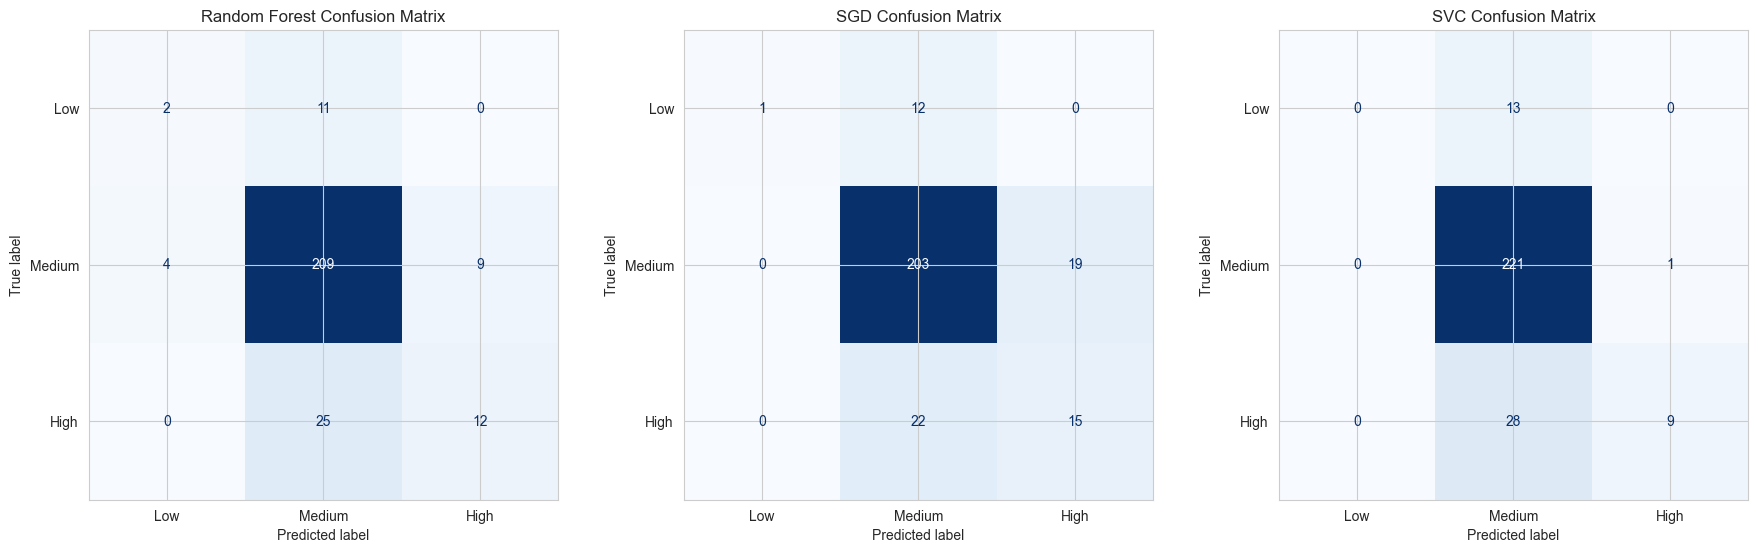

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, pred, name in zip(axes, [rf_pred, sgd_pred, svc_pred], ["Random Forest", "SGD", "SVC"]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, labels=order_groups, ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()

**What the confusion matrices show, based on the actual counts above:**

- **`Medium` is predicted correctly most often by every model** — unsurprising, since it is by far the
  largest class (Step 9) and the models have the most training examples to learn its characteristic feature
  ranges from.
- **`Low` is the class every model struggles with most.** Random Forest correctly identifies only 2 of 13
  `Low` test wines; SGD correctly identifies 1 of 13; **SVC identifies 0 of 13** — every single actual `Low`
  wine in the test set is misclassified by SVC, most often predicted as `Medium`.
- **The dominant confusion for every model is `Low`/`High` being misclassified as `Medium`**, not `Low` being
  confused with `High` directly (the two extremes are rarely confused with each other in any of the three
  matrices) — consistent with `Medium` sitting in the middle of the underlying chemistry and quality
  spectrum, so borderline low- or high-quality wines tend to drift toward the dominant middle class rather
  than jumping to the opposite extreme.
- **Minority classes clearly have weaker recall than `Medium` across all three models** — exactly the
  pattern the class-imbalance discussion in Step 6 predicted, and it is visibly confirmed here rather than
  assumed.


## Step 17 — Classification Reports

(Already printed individually per model in Steps 13–15; discussed together here.)

**Precision** (of everything the model labelled a given class, how much actually was that class) and
**recall** (of everything that truly was a given class, how much the model actually caught) tell a different
story than accuracy alone for this dataset:

- All three models have **high precision and recall on `Medium`** (roughly 0.84–0.90 precision, 0.91–1.00
  recall) — driven by its large sample size.
- **SGD's `Low` precision is 1.00 but recall is only 0.08`** — when SGD does predict `Low`, it's usually
  right, but it almost never predicts `Low` in the first place, catching only 1 of 13 actual `Low` wines.
  This is a textbook case of why precision or recall in isolation can be misleading — SGD's perfect precision
  on `Low` says nothing about how often it actually finds `Low` wines.
- **SVC's `Low` precision, recall, and F1 are all 0.00** — it never once predicts `Low` for any test wine.
- **`High` recall is modest across all models** (0.24–0.41) — better than `Low`, but still far below
  `Medium`'s.
- Because of this imbalance in per-class performance, **accuracy alone is not trusted** in this project as
  the sole basis for comparing models — see the weighted vs. macro discussion in Step 18.


## Step 18 — Model Comparison Table

Both **weighted** (each class's contribution scaled by how many true examples it has — reflects overall
real-world performance across the actual class sizes) and **macro** averaging (each class counted equally
regardless of size — reflects how well the model does across classes on average, including the small ones)
are reported, given how substantial the class imbalance is (Steps 6 and 9).

In [37]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (weighted)": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1 (weighted)": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

comparison = pd.DataFrame({
    "Random Forest": get_metrics(y_test, rf_pred),
    "SGD": get_metrics(y_test, sgd_pred),
    "SVC": get_metrics(y_test, svc_pred),
}).T.round(4)

comparison

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),Precision (macro),Recall (macro),F1 (macro)
Random Forest,0.8199,0.7899,0.8199,0.7969,0.5859,0.4732,0.5065
SGD,0.8051,0.8069,0.8051,0.7862,0.7659,0.4656,0.4833
SVC,0.8456,0.8109,0.8456,0.7974,0.5812,0.4129,0.4321


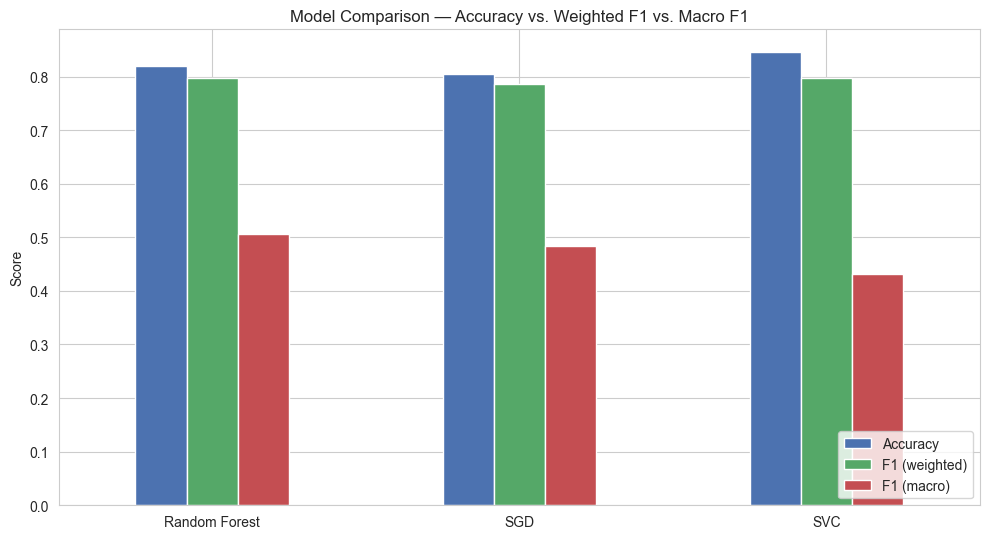

In [38]:
fig, ax = plt.subplots(figsize=(10, 5.5))
comparison[["Accuracy", "F1 (weighted)", "F1 (macro)"]].plot(kind="bar", ax=ax,
    color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Accuracy vs. Weighted F1 vs. Macro F1")
ax.set_xticklabels(comparison.index, rotation=0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Reading the table:** **SVC has the highest accuracy (≈0.85) and the highest weighted F1 (≈0.797)** —
but its **macro F1 (≈0.432) is the lowest of the three models**, dragged down entirely by its complete
failure on the `Low` class (Step 16–17). **Random Forest has slightly lower accuracy (≈0.82) but the highest
macro F1 (≈0.507)** of the three, reflecting more balanced — though still weak — performance across all three
classes rather than excelling only on the majority class. **SGD sits in between** on most metrics, with the
most unusual pattern of the three (perfect but nearly useless precision on `Low`, as discussed in Step 17).
This exact gap between accuracy/weighted-F1 and macro-F1 is precisely the situation the class-imbalance
discussion in Step 6 warned about, now backed by real numbers rather than a general caveat.

## Step 19 — Random Forest Feature Importance

In [39]:
rf = rf_model.named_steps["model"]

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns,
).sort_values(ascending=False)

feature_importance

alcohol                 0.151730
volatile acidity        0.117394
sulphates               0.113169
density                 0.091047
total sulfur dioxide    0.089182
citric acid             0.082148
fixed acidity           0.078966
residual sugar          0.076459
chlorides               0.069741
pH                      0.068442
free sulfur dioxide     0.061721
dtype: float64

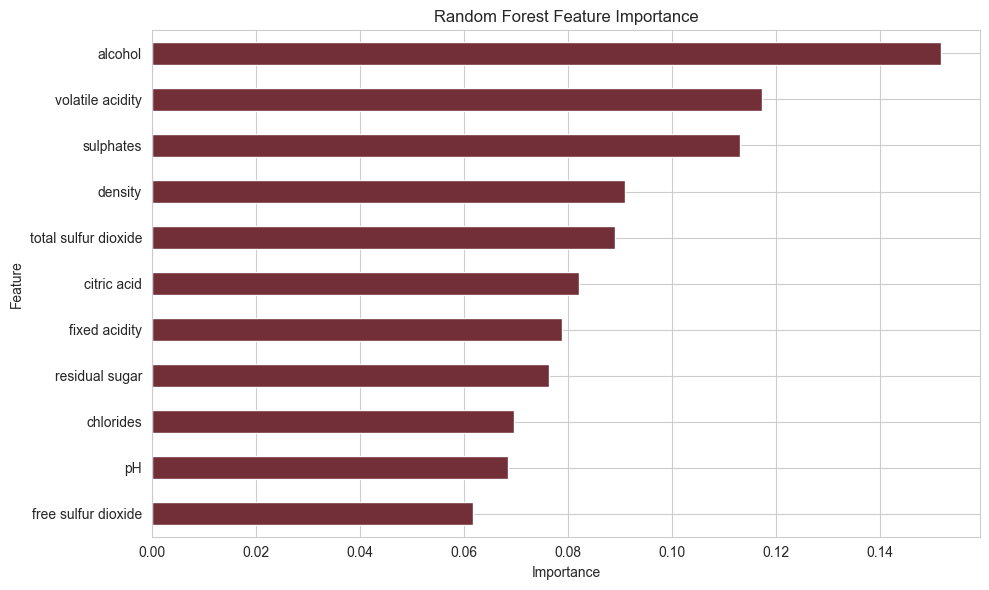

In [40]:
plt.figure(figsize=(10, 6))
feature_importance.sort_values().plot(kind="barh", color="#722F37")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Most important features (by the trained Random Forest):** `alcohol` (≈0.152), `volatile acidity`
(≈0.117), and `sulphates` (≈0.113) rank highest — and notably, these are the **same three features** that
showed the strongest correlations with `quality` in the EDA (Step 8: alcohol ≈0.48, volatile acidity ≈−0.40,
sulphates ≈0.25). The feature-importance ranking and the correlation analysis reinforce each other here,
which is a good internal-consistency check on both analyses, though they were computed by entirely different
methods (a linear correlation coefficient vs. a tree-based model's split-usefulness).

**Least important features:** `free sulfur dioxide` (≈0.062) and `pH` (≈0.068) contribute the least to the
model's splits — again consistent with their near-zero correlation with quality found in Step 8.

**Important caveat, stated explicitly per the project rules:** this ranking shows how useful each feature
was to the Random Forest's predictions on *this* dataset — it does **not** prove that, for example, adding
alcohol to a wine would improve its quality score. Several of these features are also correlated with each
other (Step 8's fixed-acidity/pH/density/citric-acid cluster), which can obscure how much of a feature's
importance is really its own signal versus signal shared with a correlated neighbor.

## Step 20 — Model Performance Analysis

**Not simply picking the highest-accuracy model.** Weighing the actual results from Steps 16–18 against
several considerations:

| Consideration | Random Forest | SGD | SVC |
|---|---|---|---|
| Accuracy | 0.8199 | 0.8051 | **0.8456** |
| Weighted F1 | 0.7969 | 0.7862 | **0.7974** |
| **Macro F1** | **0.5065** | 0.4833 | 0.4321 |
| Minority (`Low`) recall | 0.15 (2/13) | 0.08 (1/13) | **0.00 (0/13)** |
| Consistency across classes | Most balanced of the three | Extreme precision/recall split on `Low` | Best on majority, worst on minority |
| Interpretability | High — built-in feature importance (Step 19) | Moderate — linear coefficients | Lower — less directly interpretable decision boundary, especially with the default RBF kernel |
| Relative computational cost | Higher (200 trees) but still fast at this dataset size | Fastest to train | Moderate — kernel computation scales less favourably with more data |

**Trade-off discussion:** SVC wins on raw accuracy and weighted F1 — but achieves this largely by leaning on
the dominant `Medium` class and essentially giving up on `Low` entirely (0/13 correct). Random Forest trades
a small amount of accuracy and weighted F1 for meaningfully better macro F1 and modestly better minority-class
recall — a more balanced, if still imperfect, performance across all three quality groups. Given that a
central motivation of this project (Steps 1 and 6) is understanding *which* wines are lower- or
higher-quality, not just maximising overall correct-guess rate, a model that never identifies a single `Low`
wine is a meaningful practical weakness, not a minor statistical footnote — even though it has the best
headline accuracy number.

## Step 21 — Deployment Recommendation

**Which model is most suitable for deployment, and why?**

**Random Forest** is the recommended model of the three tested, based on the actual results in Step 20:

- **Predictive performance:** it has the best macro F1 (≈0.507) of the three — the metric that best reflects
  balanced performance across all quality groups rather than just the majority class — while its accuracy
  (≈0.82) and weighted F1 (≈0.797) remain close to the other two models' figures.
- **Generalization:** trained and evaluated with a stratified split preserving class proportions (Step 11),
  giving a fair like-for-like comparison; no indication in the confusion matrix (Step 16) of the kind of
  complete class collapse seen with SVC on `Low`.
- **Computational cost:** 200 trees is not the cheapest option of the three to train, but for a dataset this
  size (1,359 rows) the difference in wall-clock time between all three models is negligible in practice.
- **Interpretability:** Random Forest's feature importances (Step 19) give a genuinely useful, directly
  extractable view into which chemical properties drove its decisions — useful for the quality-control /
  production-analysis use cases described in Step 1, and something SVC's default kernel does not offer as
  directly.
- **Class imbalance:** it is not a solution to the imbalance — it still only catches 2 of 13 `Low` wines
  and 12 of 37 `High` wines in the test set — but it degrades the *least* badly on the minority classes of
  the three models tested, rather than abandoning them almost entirely as SVC does.

**This is not a claim that Random Forest is production-ready as-is.** Before any real deployment, this model
would need: substantially more `Low`- and `High`-quality training examples (ideally collected rather than
synthetically generated, to avoid introducing artificial patterns); hyperparameter tuning (e.g.
`class_weight="balanced"`, tree depth, number of estimators) specifically aimed at improving minority-class
recall rather than only overall accuracy; validation on wines from outside this particular dataset's source
and time period; and a clear specification of what error rate is acceptable for each class in the intended
use case (e.g. missing a genuinely low-quality wine may be more costly than the reverse).

## Step 22 — Final Insights

- **Dataset:** UCI red-wine quality dataset, 1,599 raw samples, reduced to **1,359** after removing 240
  duplicate rows (Step 4); 11 physicochemical features, all numeric with no missing values.
- **Quality-score distribution:** heavily concentrated on scores 5 and 6 (>80% of wines combined); scores 3
  and 8 severely underrepresented (under 2% combined) (Step 5).
- **Class imbalance:** confirmed severe in the original 6-class target; addressed (not eliminated) by
  grouping into `Low`/`Medium`/`High`, resulting in a still-imbalanced but far more workable
  ~4.6%/81.8%/13.5% split (Steps 6, 9).
- **Important physicochemical features:** `alcohol`, `volatile acidity`, and `sulphates` are consistently the
  strongest predictors, confirmed by both the correlation analysis (Step 8) and the Random Forest's feature
  importance (Step 19).
- **Model performance:** Random Forest accuracy ≈0.82 / weighted F1 ≈0.797 / macro F1 ≈0.507; SGD accuracy
  ≈0.81 / weighted F1 ≈0.786 / macro F1 ≈0.483; SVC accuracy ≈0.85 / weighted F1 ≈0.797 / macro F1 ≈0.432
  (Step 18).
- **Best-performing model:** Random Forest, chosen on macro F1 and minority-class behaviour rather than
  accuracy alone (Steps 20–21).
- **Weaknesses:** all three models struggle substantially with the `Low` quality group, and SVC in particular
  never correctly identifies a single `Low` wine in the test set — a direct, measured consequence of the
  small number of `Low` training examples (Step 9).
- **Implications:** physicochemical measurements alone carry real but limited signal about wine quality —
  strong enough to reliably separate typical (`Medium`) wines from the rest, much weaker at reliably catching
  the comparatively rare high- and especially low-quality wines with the amount of data available here.


## Step 23 — Real-World Application

Based on what this model actually demonstrated it can and cannot do (Steps 16–21):

- **Quality-control assistance:** flagging batches whose chemistry (e.g. unusually low alcohol, high volatile
  acidity) resembles patterns seen in lower-scoring wines, for closer human review — not as an automatic
  pass/fail judgment.
- **Wine-production analysis:** using the feature-importance findings (Step 19) to focus process improvements
  on the chemical properties shown to matter most in this dataset (alcohol content, volatile acidity,
  sulphates), while remembering these are associations, not proven causes.
- **Screening wines for further human evaluation:** given the model is reasonably reliable at identifying
  `Medium` (typical) wines but weak on the extremes, it is better suited to a triage role — e.g. flagging
  anything *not* confidently predicted as `Medium` for a taster's attention — than to independently sorting
  wines into final quality tiers.
- **Identifying important physicochemical characteristics:** a genuinely supported use, directly backed by
  Step 19's results.
- **Decision support, not decision replacement:** given the model's measured, substantial weakness on
  minority classes (Steps 16–18), it should support rather than automatically replace expert quality
  assessment — consistent with the framing set out in Step 1's introduction.


## Step 24 — Limitations

- **Severe class imbalance**, even after grouping (Step 9): `Low` and `High` together make up under 20% of
  the dataset, directly limiting how well any of the three models could learn to recognise them (demonstrated
  concretely in Steps 16–18).
- **Relatively small number of examples for the `Low` class specifically** — only 63 wines in the entire
  1,359-row dataset, 50 in training and 13 in test, which is too few to draw strong conclusions about the
  model's real-world reliability on genuinely low-quality wine.
- **Subjective nature of the quality labels:** the `quality` score is an average of human tasters' subjective
  ratings, not a directly measured physical quantity — some of the "noise" a model cannot explain may simply
  reflect genuine disagreement or inconsistency between tasters, not a shortcoming of the chemical features.
- **Limited physicochemical variables:** only 11 measured properties are available; factors known to
  influence wine quality in practice (grape variety, vintage, winemaking process, storage conditions) are not
  recorded in this dataset and cannot be modeled.
- **Red wine only:** this notebook used the red-wine dataset specifically (Step 1); the physicochemical
  relationships to quality may differ for white wine, and this model should not be assumed to generalise to
  it without separate testing.
- **240 duplicate rows removed:** while justified in Step 4, this assumes the duplicates were genuinely
  repeated records rather than coincidentally identical distinct samples — a reasonable but not
  absolutely certain assumption given the available information.
- **Test-set performance does not guarantee real-world performance:** the test set is a 20% random
  (stratified) split of the same dataset and time period as the training data — it does not represent an
  independent, truly out-of-sample validation on wines from different producers, regions, or years.


## Step 25 — Conclusion

**Objective:** predict wine-quality categories from physicochemical measurements and compare Random Forest,
SGD, and SVC classifiers on the UCI red-wine dataset.

**What the EDA revealed:** the dataset is clean (no missing values) but contained 240 duplicate rows
(15%, removed); the `quality` target is concentrated overwhelmingly in scores 5 and 6, with scores 3 and 8
almost absent; `alcohol`, `volatile acidity`, and `sulphates` showed the strongest relationships with quality.

**Was class imbalance present?** Yes — severely, in the original 6-class target, and still meaningfully
(~82% `Medium`) even after grouping into three broader classes, a decision made explicitly to make the
classification problem more tractable rather than to artificially inflate performance.

**How did the three models perform?** Random Forest: accuracy ≈0.82, weighted F1 ≈0.797, macro F1 ≈0.507.
SGD: accuracy ≈0.81, weighted F1 ≈0.786, macro F1 ≈0.483. SVC: accuracy ≈0.85, weighted F1 ≈0.797, macro F1
≈0.432 — the highest accuracy of the three but the weakest, most imbalanced per-class behaviour, including a
complete failure to identify any `Low`-quality wine in the test set.

**Which model performed best?** Random Forest, on the basis of macro F1 and more consistent (if still
imperfect) behaviour across all three quality groups, not on accuracy alone.

**Recommendation:** Random Forest, for the reasons detailed in Step 21 — best balance of accuracy,
macro-level performance, minority-class behaviour, and interpretability among the three models tested.

**Before deployment:** more `Low`- and `High`-quality training examples, hyperparameter tuning aimed
specifically at minority-class recall, out-of-sample validation beyond this single dataset, and a clear,
context-specific decision about acceptable error rates per class — this project demonstrates a genuine,
evidence-based comparison of three classifiers, not a production-ready wine-quality system.
